# Instalando Bibliotecas

In [1]:
import numpy as np
import pandas as pd
import datetime as dt
import warnings

import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf as _plot_acf
from statsmodels.graphics.tsaplots import plot_pacf as _plot_pacf
from sklearn.metrics import ConfusionMatrixDisplay

import statsmodels
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
import pmdarima as pm
from prophet import Prophet

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.svm import SVC

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.datasets import fetch_olivetti_faces
from sklearn.cluster import KMeans

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
    accuracy_score,
    precision_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)
from sklearn.exceptions import UndefinedMetricWarning


c:\Users\rafae\OneDrive\Documentos\GitHub\PosTech-Phasis-2\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Trazendo e transformando dados

In [26]:
ibov = pd.read_csv('IbovDef.csv', sep=',')
ibov.shape

(6388, 7)

## Definindo Funções

In [27]:
def vol(valor):
    valor = str(valor).strip()

    if valor == "" or valor.lower() == "nan":
        return 0

    multiplicador = 1
    if valor.endswith("K"):
        multiplicador = 1000
        valor = valor[:-1]
    elif valor.endswith("M"):
        multiplicador = 1000000
        valor = valor[:-1]
    elif valor.endswith("B"):
        multiplicador = 1000000000
        valor = valor[:-1]

    valor = valor.replace(".", "").replace(",", ".", valor.count(".")-1)
    try:
        return float(valor) * multiplicador
    except ValueError:
        return 0.0

def direcao(var):
    if var > 0:
        return "Subiu"
    elif var < 0:
        return "Desceu"
    else:
        return "Neutro"

def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    return mae, mse, mape

def print_metrics(metrics):
    mae, mse, mape = metrics
    print(f"MAE: {mae}")
    print(f"MSE: {mse}")
    print(f"MAPE: {mape:.2f} %")

def substitui_dots(s):
    parts = s.split(".")
    last = parts[-1]
    if len(last) == 3:
        numeric = "".join(parts)
        return float(numeric) 
    else:
        left = "".join(parts[:-1])
        right = last.ljust(3, "0")
        numeric = left + right
        return float(numeric)

def prepara_metricas(df):
    for w in [3, 7, 14, 21, 30]: #Médias móveis
        df[f"mm_{w}"] = df["Último"].rolling(w).mean() 
        df["dif_mm3"] = df["Último"] - df["mm_3"]

    for w in [5, 10, 20]: #Volatilidade
        df[f"vol_{w}"] = df["Último"].rolling(w).std()

    return df

## Manipulando dados

In [28]:
ibov["Var%"] = ibov["Var%"].str.replace("%", "").str.replace(",", ".").astype(float)

for col in ['Último', 'Abertura', 'Máxima', 'Mínima']:
    ibov[col] = ibov[col].astype(str).apply(substitui_dots)

ibov['Data'] = pd.to_datetime(ibov['Data'].astype(str), format='%d.%m.%Y')
ibov = ibov.sort_values(by="Data", ascending=True)

ibov["Vol."] = ibov["Vol."].apply(vol)
ibov["Direção"] = ibov["Var%"].apply(direcao)
ibov = prepara_metricas(ibov)

ibov = ibov[ibov["Direção"] != "Neutro"]
ibov = ibov.dropna(subset=['mm_30'])

ibov = ibov.reset_index(drop=True)
ibov.head()

,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%,Direção,mm_3,dif_mm3,mm_7,mm_14,mm_21,mm_30,vol_5,vol_10,vol_20
0,2000-02-14,17819.0,18083.0,18264.0,17746.0,772930000.0,-1.46,Desceu,18168.666667,-349.666667,18230.142857,17554.714286,17525.380952,17232.833333,361.601023,710.935503,686.788167
1,2000-02-15,17921.0,17818.0,17932.0,17451.0,919500000.0,0.57,Subiu,17941.000000,-20.000000,18228.571429,17613.000000,17537.904762,17265.866667,322.815427,538.140017,682.001410
2,2000-02-16,18112.0,17921.0,18247.0,17743.0,111360000.0,1.07,Subiu,17950.666667,161.333333,18226.571429,17686.642857,17540.714286,17341.233333,302.136890,367.921625,689.861344
3,2000-02-17,17979.0,18116.0,18297.0,17979.0,683210000.0,-0.73,Desceu,18004.000000,-25.000000,18125.571429,17775.571429,17544.333333,17399.033333,119.788146,294.711931,697.168897
4,2000-02-18,17625.0,17979.0,18008.0,17489.0,733360000.0,-1.97,Desceu,17905.333333,-280.333333,18020.428571,17863.928571,17551.714286,17449.633333,182.636798,334.651460,691.796021


### Métricas opcionais (Comentadas)

In [ ]:
# ibov["Lag1"] = ibov['Último'].shift(1)
# ibov["Lag5"] = ibov['Último'].shift(5)
# ibov["MM7"] = ibov['Último'].rolling(window=7).mean()
# ibov["Ab_x_MM7"] = ibov['Abertura'] - ibov['MM7']
# ibov["MM15"] = ibov['Último'].rolling(window=15).mean()
# ibov["MM30"] = ibov['Último'].rolling(window=30).mean()
# ibov["MM7_x_MM30"] = ibov['MM7'] - ibov['MM30']
# ibov["MM60"] = ibov['Último'].rolling(window=60).mean()
# ibov["MM30_x_MM60"] = ibov['MM30'] - ibov['MM60']
# ibov["MMVol5"] = ibov['Vol.'].rolling(window=5).mean()
# ibov["VarAbs"] = ibov['Máxima'] - ibov['Mínima']
# ibov.dropna(subset=['MM60'], inplace=True)
#ibov = ibov.sort_values(by="Data", ascending=False)

## Analisando Dados transformados

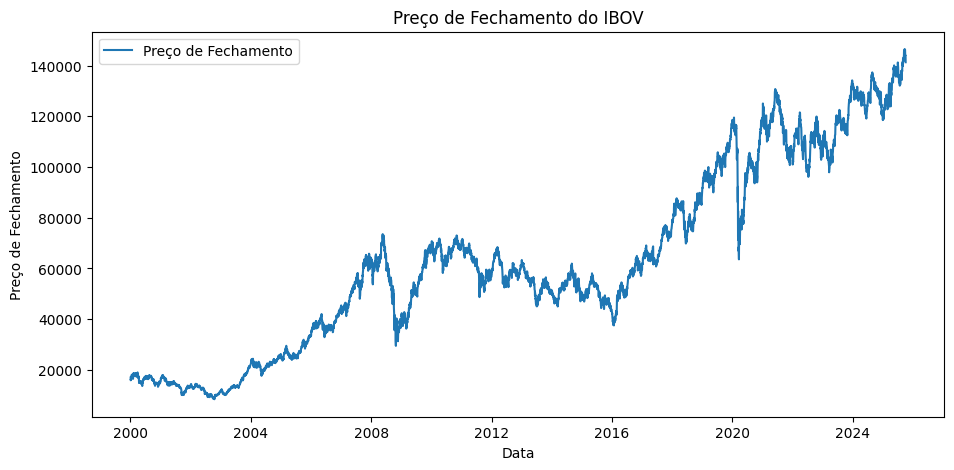

In [481]:
plt.figure(figsize=(11, 5))
plt.plot(ibov['Data'], ibov["Último"], label="Preço de Fechamento")
plt.title("Preço de Fechamento do IBOV")
plt.xlabel("Data")
plt.ylabel("Preço de Fechamento")
plt.legend()
plt.show()

## Seasonal Decompose e diferenciação

<Axes: >

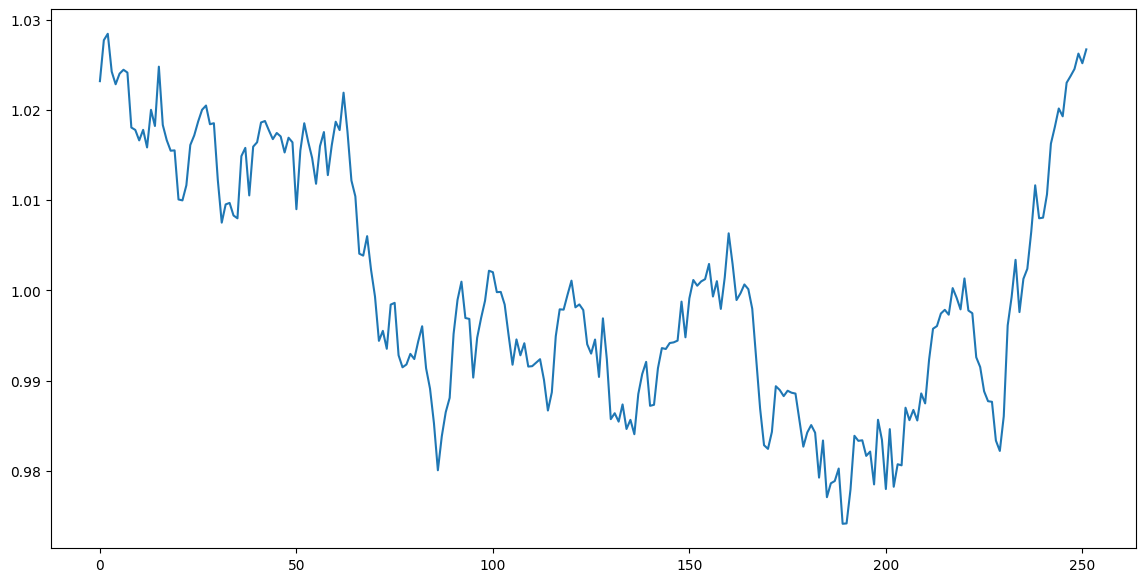

In [462]:
result = seasonal_decompose(ibov["Último"], model="multiplicative", period=252)
result.seasonal.iloc[:252].plot(figsize=(14, 7))

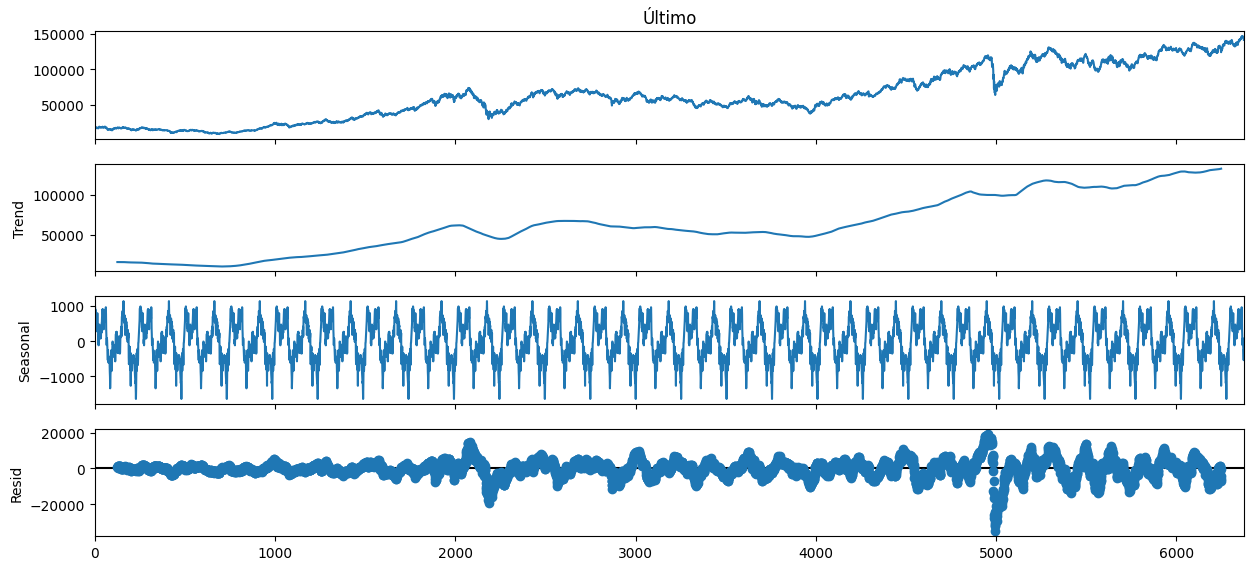

In [463]:
result = seasonal_decompose(ibov["Último"], model="additive", period=252)
fig = result.plot()
fig.set_size_inches(14, 6)

In [464]:
def plot_acf(data, lags=365, title="Autocorrelação da Série Temporal"):

    fig, ax = plt.subplots(figsize=(15, 5))
    # Get the ACF values and confidence intervals
    _plot_acf(data, lags=lags, ax=ax, alpha=0.05)
    ax.set_title(title)
    ax.set_xlabel("Lags")
    ax.set_ylabel("Autocorrelação")
    fig.set_tight_layout(True)

    acf_x = sm.tsa.acf(data, alpha=0.05, nlags=700)
    acf, ci = acf_x[:2]
    intercept_point = np.where(abs(acf) < (ci[:, 1] - acf))
    if intercept_point[0].size > 0:
        print(
            f"The ACF coefficients intercept the threshold at lag {intercept_point[0][0]}"
        )
    else:
        print("The ACF coefficients do not intercept the threshold")

The ACF coefficients intercept the threshold at lag 539


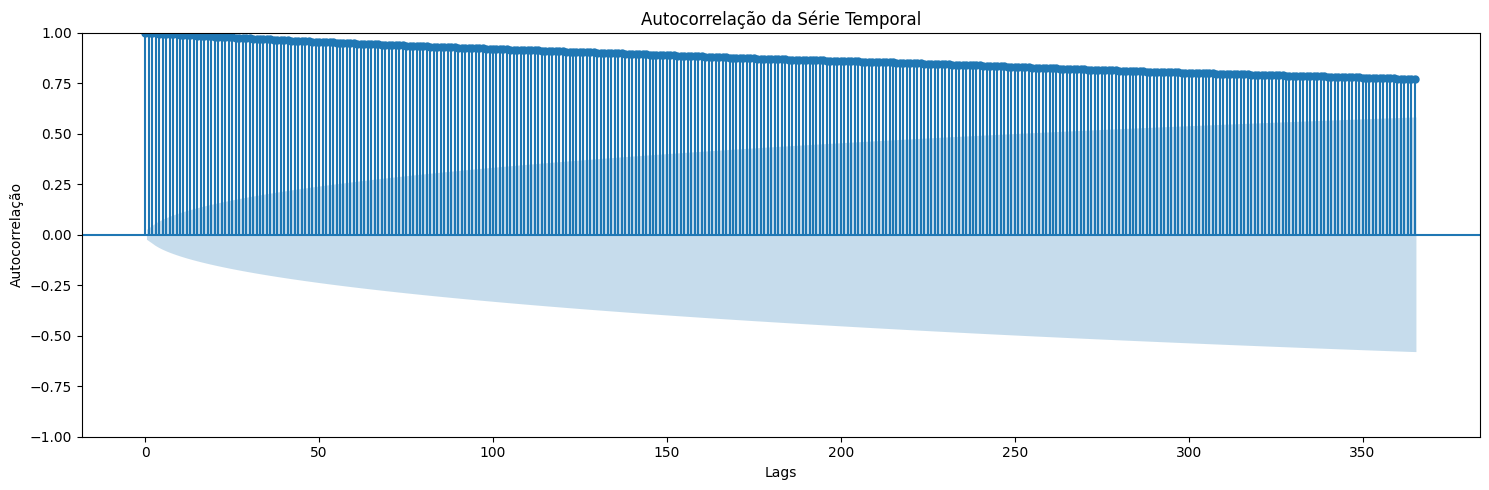

In [465]:
plot_acf(ibov["Último"])

The PACF coefficients intercept the threshold at lag 2


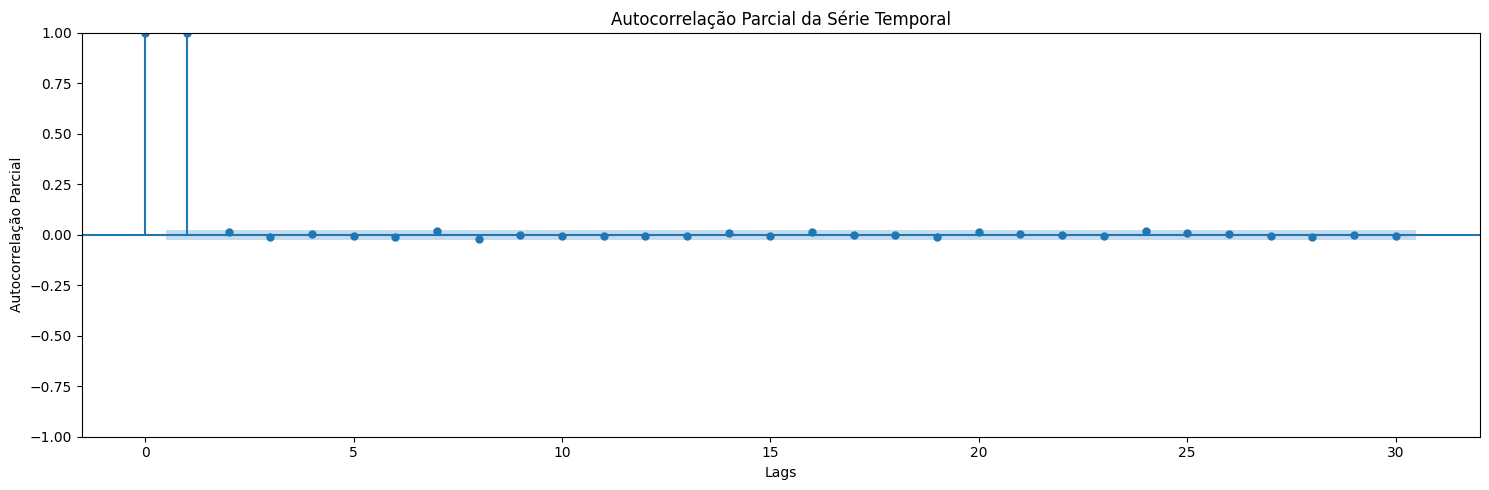

In [466]:
from statsmodels.graphics.tsaplots import plot_pacf as _plot_pacf

def plot_pacf(data, lags=30, title="Autocorrelação Parcial da Série Temporal"):

    fig, ax = plt.subplots(figsize=(15, 5))
    # Get the ACF values and confidence intervals
    _plot_pacf(data, lags=lags, ax=ax, alpha=0.05)
    ax.set_title(title)
    ax.set_xlabel("Lags")
    ax.set_ylabel("Autocorrelação Parcial")
    fig.set_tight_layout(True)

    acf_x = sm.tsa.pacf(data, alpha=0.05, nlags=lags)
    acf, ci = acf_x[:2]
    intercept_point = np.where(abs(acf) < (ci[:, 1] - acf))
    if intercept_point[0].size > 0:
        print(
            f"The PACF coefficients intercept the threshold at lag {intercept_point[0][0]}"
        )
    else:
        print("The PACF coefficients do not intercept the threshold")
        
plot_pacf(ibov["Último"])

In [467]:
adf_result = sm.tsa.adfuller(ibov["Último"])
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")
print(f"Critical Values: {adf_result[4]}")

if adf_result[1] < 0.05:
    print("A série temporal é estacionária")
else:
    print("A série temporal não é estacionária")

ADF Statistic: -0.5156228031068762
p-value: 0.8889315861591063
Critical Values: {'1%': -3.4313781219590926, '5%': -2.8619943401537546, '10%': -2.5670118421276804}
A série temporal não é estacionária


<Axes: >

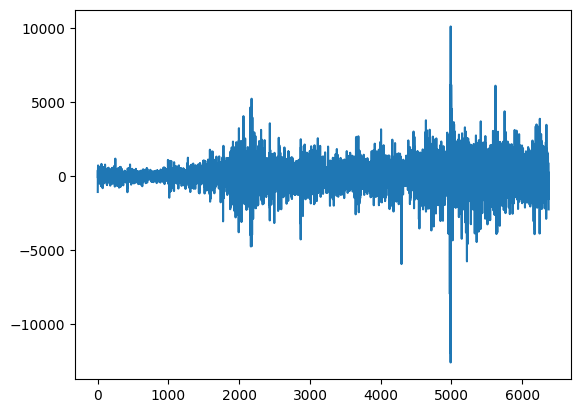

In [468]:
ibov["Último"].diff().plot()

In [469]:
adf_result = sm.tsa.adfuller(ibov["Último"].diff().dropna())
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")
print(f"Critical Values: {adf_result[4]}")

if adf_result[1] < 0.05:
    print("A série temporal é estacionária")
else:
    print("A série temporal não é estacionária")

ADF Statistic: -22.22802995253207
p-value: 0.0
Critical Values: {'1%': -3.4313781219590926, '5%': -2.8619943401537546, '10%': -2.5670118421276804}
A série temporal é estacionária


In [470]:
acf_x = sm.tsa.acf(ibov["Último"], alpha=0.05, nlags=1000)
acf, ci = acf_x[:2]

# identificação do q pelo ponto de interceptação ao 95% com o acf
q = np.where(abs(acf) < (ci[:, 1] - acf))[0][0]

pacf_x = sm.tsa.pacf(ibov["Último"], alpha=0.05, nlags=30)
pacf, ci = pacf_x[:2]

# identificação do p pelo ponto de interceptação ao 95% com o pacf
p = np.where(abs(pacf) < (ci[:, 1] - pacf))[0][0]

d = 1
print(p, q, d)

2 539 1


In [471]:
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [472]:
model = pm.auto_arima(
    ibov["Último"],
    seasonal=True,
    m=12,
    stepwise=True,
)

print(model.summary())

seasonal_order = model.seasonal_order
print(f"Detected Seasonal Order: {seasonal_order}")

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 6375
Model:               SARIMAX(2, 1, 2)   Log Likelihood              -53208.862
Date:                qua, 08 out 2025   AIC                         106427.724
Time:                        21:58:53   BIC                         106461.524
Sample:                             0   HQIC                        106439.426
                               - 6375                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.5244      0.038    -40.628      0.000      -1.598      -1.451
ar.L2         -0.6965      0.035    -19.963      0.000      -0.765      -0.628
ma.L1          1.4638      0.040     36.821      0.0

## Montagem de df treino e teste

In [482]:
train_size = ibov.shape[0] - 30
train, test = ibov[:train_size], ibov[train_size:]

def create_features(df):
    df["Data"] = pd.to_datetime(df["Data"])
    df["year"] = df["Data"].dt.year
    df["month"] = df["Data"].dt.month
    df["day"] = df["Data"].dt.day
    df["dayofweek"] = df["Data"].dt.dayofweek
    df["delta1"] = df["Último"].diff().shift(-1)
    df["delta5"] = df["Último"].diff().shift(-5)
    df["MM7"] = df['Último'].rolling(window=7).mean()
    df["MM3"] = df['Último'].rolling(window=3).mean()
    df["MM3-7"] = df['MM7'] - df['MM3']
    df['Var%'] = df['Var%']
    df['Vol.'] = df['Vol.']
    df["daily_return"] = ((df["Último"] - df["Abertura"]) / df["Abertura"]).shift(-1)
    return df


train = create_features(train)
test = create_features(test)

FEATURES = ["year", "month", "day", "dayofweek", "Abertura", "delta1", "delta5", "daily_return", "MM3", "MM7", "MM3-7", "Vol."]
TARGET = "Var%"

X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

C:\Users\rafae\AppData\Local\Temp\ipykernel_8924\2247378326.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Data"] = pd.to_datetime(df["Data"])
C:\Users\rafae\AppData\Local\Temp\ipykernel_8924\2247378326.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["year"] = df["Data"].dt.year
C:\Users\rafae\AppData\Local\Temp\ipykernel_8924\2247378326.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

S

# XGBoost

In [475]:
reg = xgb.XGBRegressor(objective="reg:squarederror")
reg.fit(X_train, y_train)

preds = reg.predict(X_test)
metrics_xgb = calculate_metrics(y_test, preds)
print("XGBoost Metrics:")
print_metrics(metrics_xgb)

real_direction = test["Direção"].reset_index(drop=True)

pred_diff = np.diff(preds, prepend=preds[0]) 
pred_direction = (pred_diff > 0).astype(int)  
pred_direction_label = pd.Series(pred_direction).replace({1: "Subiu", 0: "Desceu"})

mask = ~pd.Series(pred_direction_label).isna()

acc_xgb = (real_direction[mask].reset_index(drop=True) == pred_direction_label[mask].reset_index(drop=True)).mean()

print(f"Acurácia Direcional XGBoost: {acc_xgb:.2%}")

XGBoost Metrics:
MAE: 1.1957855182439088
MSE: 3.294193227511913
MAPE: 330.22 %
Acurácia Direcional XGBoost: 46.67%


# Prophet

In [476]:
train_prophet = train.rename(columns={"Data": "ds", "Var%": "y"})
test_prophet = test.rename(columns={"Data": "ds", "Var%": "y"})

model = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True, )
model.add_regressor("Vol.")
model.fit(train_prophet)

future = model.make_future_dataframe(periods=len(test))
future["Vol."] = pd.concat([train["Vol."], test["Vol."]], ignore_index=True)
forecast = model.predict(future)

preds = forecast[["ds", "yhat"]].tail(len(test))
preds = preds.set_index("ds")
y_test = test_prophet.set_index("ds")["y"]

metrics_pr = calculate_metrics(y_test, preds["yhat"])
print("Prophet Metrics:")
print_metrics(metrics_pr)

real_direction = (y_test.diff() > 0).astype(int)  
pred_direction = (preds["yhat"].diff() > 0).astype(int)

real_direction, pred_direction = real_direction.align(pred_direction, join="inner")

mask = ~pred_direction.isna()

acc_proph = (real_direction[mask].reset_index(drop=True) == pred_direction[mask].reset_index(drop=True)).mean()
print(f"Acurácia Direcional Prophet: {acc_proph:.2%}")

21:58:53 - cmdstanpy - INFO - Chain [1] start processing
21:58:54 - cmdstanpy - INFO - Chain [1] done processing


Prophet Metrics:
MAE: 0.5544797661113754
MSE: 0.4618103477864437
MAPE: 93.61 %
Acurácia Direcional Prophet: 59.09%


# SARIMAX

In [477]:
exog_train = train[["Vol."]]
exog_test = test[["Vol."]]

model = sm.tsa.statespace.SARIMAX(
    train["Var%"],
    exog=exog_train,
    order=(
        p,
        d,
        1, # Diminuir o "q" para otimizar processamento
    ),  
    seasonal_order=(0, 0, 0, 12),
)
results = model.fit()

preds = results.get_forecast(steps=len(test), exog=exog_test).predicted_mean

metrics_sarimax = calculate_metrics(test["Var%"], preds)
print("SARIMAX Metrics:")
print_metrics(metrics_sarimax)

real_direction = test["Direção"].reset_index(drop=True)

pred_direction = (preds.diff() > 0).astype(int).reset_index(drop=True)
pred_direction_label = pred_direction.replace({1: "Subiu", 0: "Desceu"})
mask = ~pred_direction.isna()

acc_smx = (real_direction[mask].reset_index(drop=True) == pred_direction_label[mask]).mean()

print(f"Acurácia de direção: {acc_smx:.2%}")

SARIMAX Metrics:
MAE: 0.5884182823611223
MSE: 0.5187733405800905
MAPE: 131.19 %
Acurácia de direção: 63.33%


# Resultados

In [478]:
pred_sarimax = preds
pred_prophet = forecast["yhat"].tail(len(test))
pred_xgboost = reg.predict(X_test)

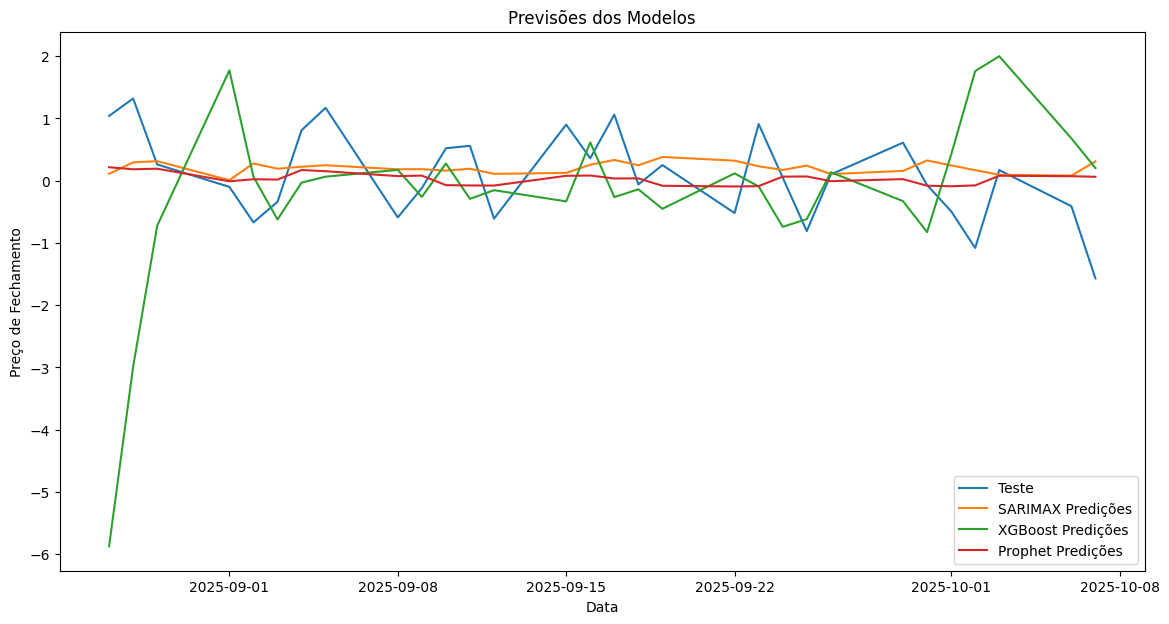

In [479]:
plt.figure(figsize=(14, 7))
plt.plot(test["Data"], test["Var%"], label="Teste")
plt.plot(test["Data"], pred_sarimax, label="SARIMAX Predições")
plt.plot(test["Data"], pred_xgboost, label="XGBoost Predições")
plt.plot(test_prophet["ds"], pred_prophet, label="Prophet Predições")
plt.title("Previsões dos Modelos")
plt.xlabel("Data")
plt.ylabel("Preço de Fechamento")
#plt.ylim(bottom=125000)
plt.legend()

In [480]:
df = pd.DataFrame(
    [metrics_xgb, metrics_pr, metrics_sarimax],
    columns=["MAE", "MSE", "MAPE"],
    index=["XGBoost", "Prophet", "SARIMAX"],
)
df.sort_values(by="MAPE", ascending=True).applymap(lambda x: f"{x:0.2f}" if isinstance(x, (int, float)) else x)

,MAE,MSE,MAPE
Prophet,0.55,0.46,93.61
SARIMAX,0.59,0.52,131.19
XGBoost,1.20,3.29,330.22
